In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import numpy as np

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:

def visualize_echocardiogram_2d(base_path, image_path, label_path):
    # 1. Load the NIfTI data
    # These files in 'extracted_frames' are 2D slices
    img_data = nib.load(os.path.join(base_path, image_path)).get_fdata()
    lbl_data = nib.load(os.path.join(base_path, label_path)).get_fdata()

    # 2. Handle dimensionality
    # If the file is strictly 2D, its shape is (H, W). 
    # If it has a singleton 3rd dimension (H, W, 1), we squeeze it.
    img_slice = img_data.squeeze()
    lbl_slice = lbl_data.squeeze()

    # 3. Create the inline plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Plot Raw Ultrasound (Grayscale)
    axes[0].imshow(img_slice.T, cmap='gray', origin='lower')
    axes[0].set_title(f"Ultrasound: {image_path}")
    axes[0].axis('off')

    # Plot Segmentation Mask (Colorized)
    # Using 'jet' or 'viridis' makes the different cardiac structures stand out
    axes[1].imshow(lbl_slice.T, cmap='jet', origin='lower')
    axes[1].set_title(f"Label Mask: {label_path}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show() # In Jupyter, this renders the image in your browser


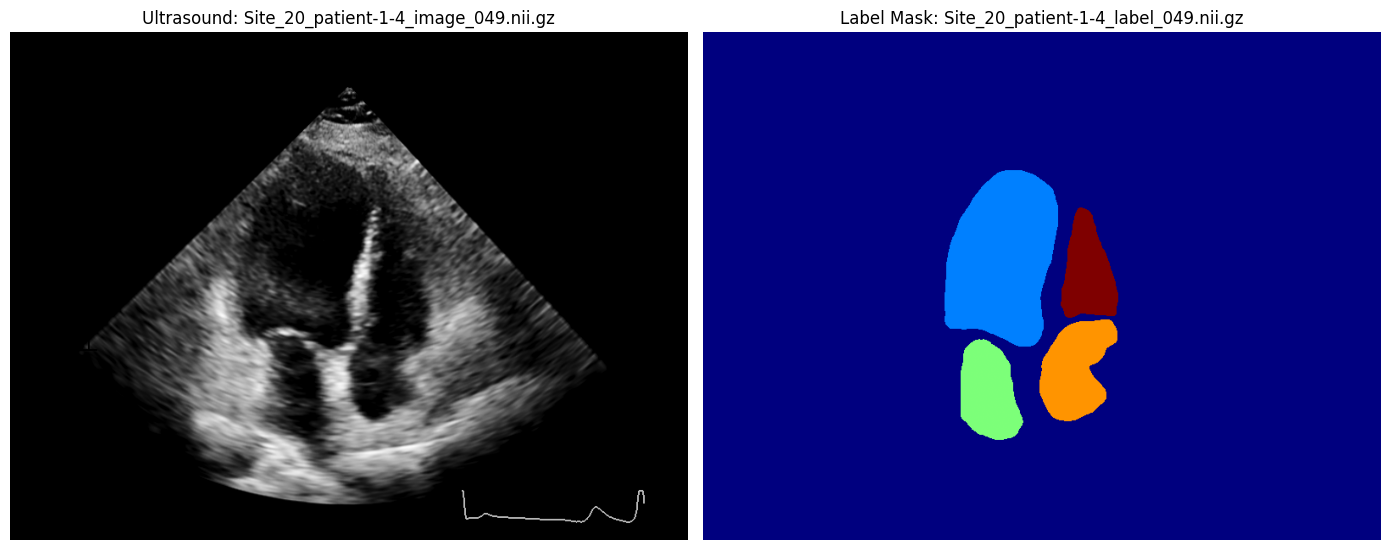

In [7]:
# Define the paths to the extracted 2D frames
base_path = "/work/cardiacUDC_dataset/extracted_frames"
image_file = "Site_20_patient-1-4_image_049.nii.gz"
label_file = "Site_20_patient-1-4_label_049.nii.gz"

# Run the visualization
visualize_echocardiogram_2d(base_path, image_file, label_file)

In [12]:
def visualize_superposition(base_path, image_path, label_path, alpha=0.5):
    # 1. Load the NIfTI data
    img_data = nib.load(os.path.join(base_path, image_path)).get_fdata()
    lbl_data = nib.load(os.path.join(base_path, label_path)).get_fdata()

    # 2. Prepare 2D slices
    img_slice = img_data.squeeze()
    lbl_slice = lbl_data.squeeze()

    # 3. Create the plot
    plt.figure(figsize=(10, 10))

    # Plot the base Ultrasound Image (Background)
    plt.imshow(img_slice.T, cmap='gray', origin='lower')

    # Create a masked version of the label to ignore background (0)
    # This prevents the background color of the mask from washing out the image
    masked_label = np.ma.masked_where(lbl_slice == 0, lbl_slice)

    # Plot the Label Mask (Overlay)
    # 'alpha' controls the transparency (lower is more transparent)
    plt.imshow(masked_label.T, cmap='jet', origin='lower', alpha=alpha)

    plt.title(f"Superposition View: {image_path} with Mask Overlay")
    plt.axis('off')
    plt.show()

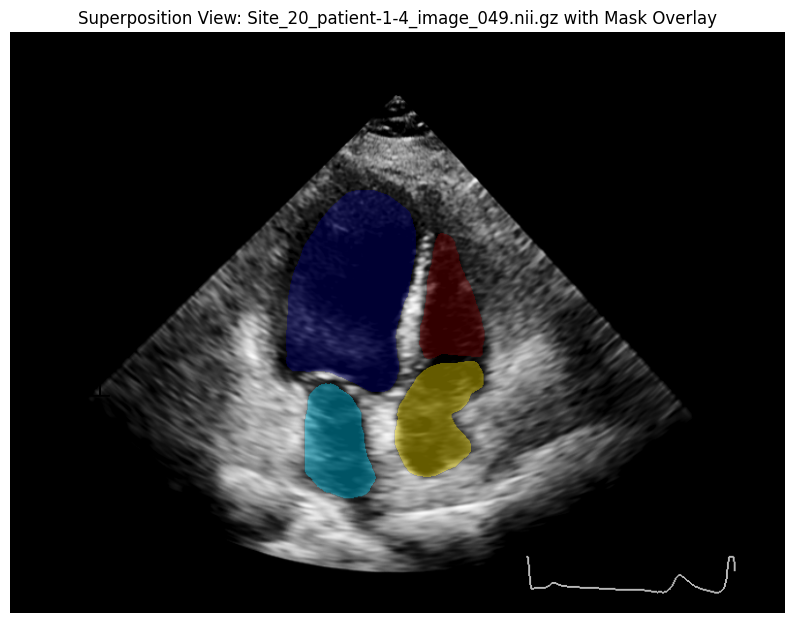

In [13]:
base_path = "/work/cardiacUDC_dataset/extracted_frames"
image_file = "Site_20_patient-1-4_image_049.nii.gz"
label_file = "Site_20_patient-1-4_label_049.nii.gz"

visualize_superposition(base_path, image_file, label_file, alpha=0.4)